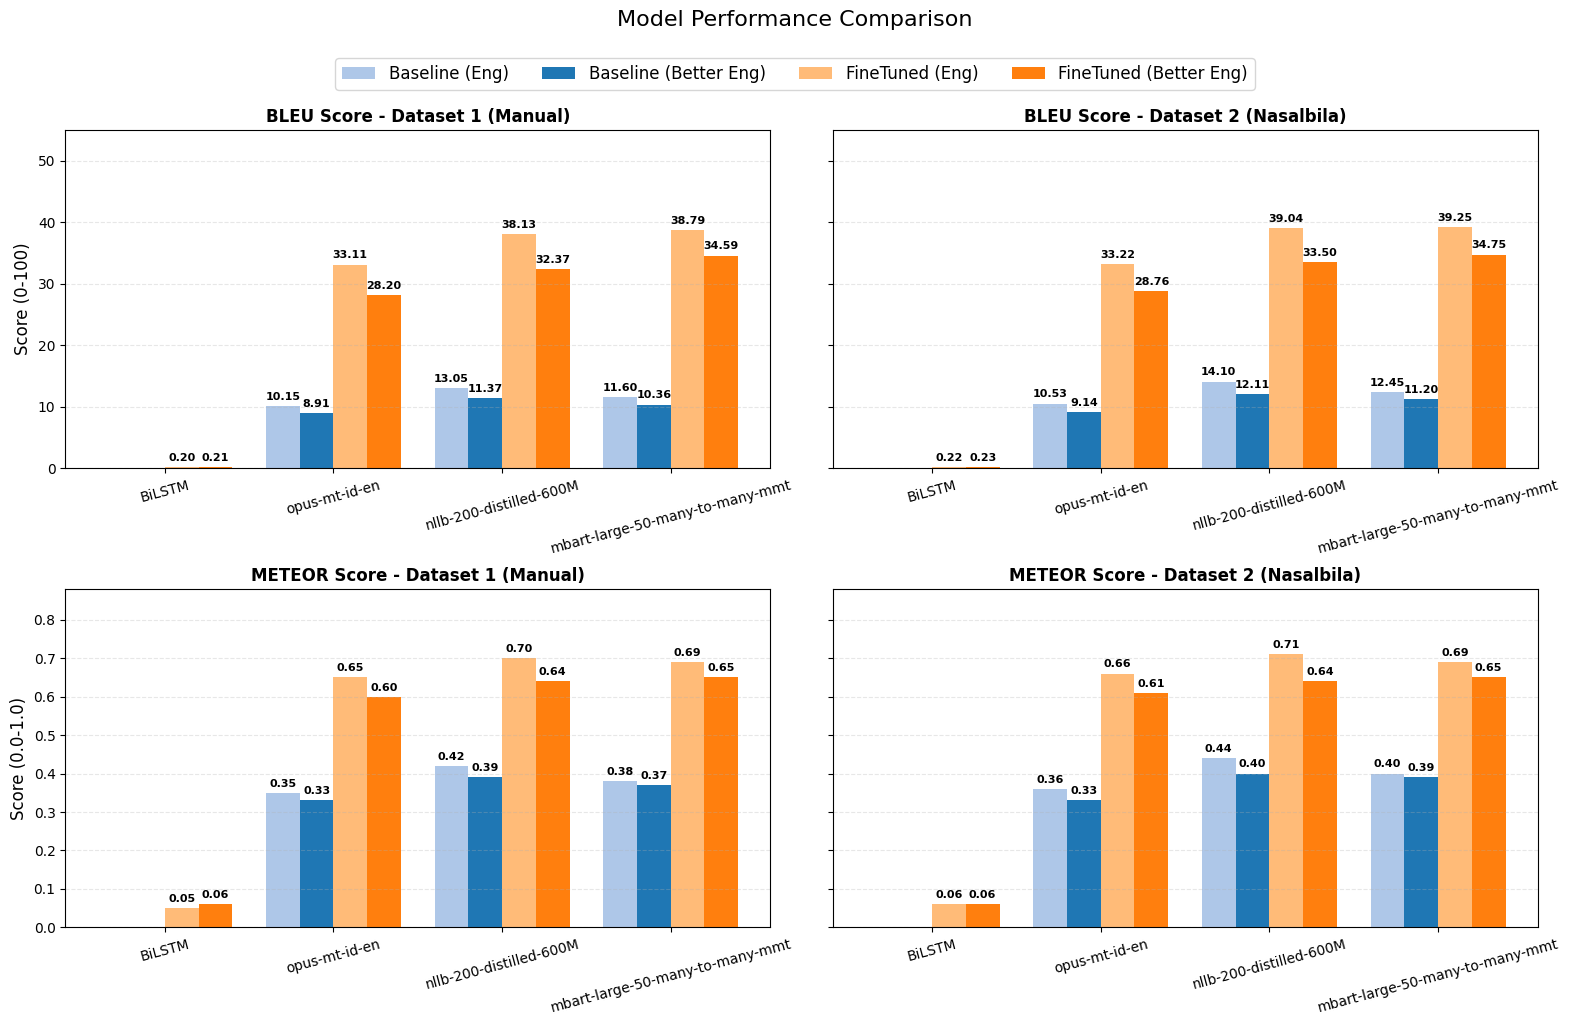

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BiLSTM', 'opus-mt-id-en', 'nllb-200-distilled-600M', 'mbart-large-50-many-to-many-mmt']

# --- DATASET 1 (Manual) ---
d1_bleu_base_eng    = [0, 10.15, 13.05, 11.60]
d1_bleu_base_better = [0, 8.91, 11.37, 10.36]
d1_bleu_ft_eng      = [0.20, 33.11, 38.13, 38.79]
d1_bleu_ft_better   = [0.21, 28.20, 32.37, 34.59]

d1_meteor_base_eng    = [0, 0.35, 0.42, 0.38]
d1_meteor_base_better = [0, 0.33, 0.39, 0.37]
d1_meteor_ft_eng      = [0.05, 0.65, 0.70, 0.69]
d1_meteor_ft_better   = [0.06, 0.60, 0.64, 0.65]

# --- DATASET 2 (Nalsabila) ---
d2_bleu_base_eng    = [0, 10.53, 14.10, 12.45]
d2_bleu_base_better = [0, 9.14, 12.11, 11.20]
d2_bleu_ft_eng      = [0.22, 33.22, 39.04, 39.25]
d2_bleu_ft_better   = [0.23, 28.76, 33.50, 34.75]

d2_meteor_base_eng    = [0, 0.36, 0.44, 0.40]
d2_meteor_base_better = [0, 0.33, 0.40, 0.39]
d2_meteor_ft_eng      = [0.06, 0.66, 0.71, 0.69]
d2_meteor_ft_better   = [0.06, 0.61, 0.64, 0.65]

all_data = [
    [[d1_bleu_base_eng, d1_bleu_base_better, d1_bleu_ft_eng, d1_bleu_ft_better],
     [d2_bleu_base_eng, d2_bleu_base_better, d2_bleu_ft_eng, d2_bleu_ft_better]],
    [[d1_meteor_base_eng, d1_meteor_base_better, d1_meteor_ft_eng, d1_meteor_ft_better],
     [d2_meteor_base_eng, d2_meteor_base_better, d2_meteor_ft_eng, d2_meteor_ft_better]]
]

row_labels = ['BLEU Score', 'METEOR Score']
col_labels = ['Dataset 1 (Manual)', 'Dataset 2 (Nasalbila)']
bar_labels = ['Baseline (Eng)', 'Baseline (Better Eng)', 'FineTuned (Eng)', 'FineTuned (Better Eng)']
colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e']

x = np.arange(len(models))
width = 0.2

# Limits
row_limits = [
    (0, 50),   # BLEU Limit
    (0, 0.8)   # METEOR Limit
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharey='row')

for r in range(2):
    for c in range(2):
        ax = axes[r, c]
        dataset_scores = all_data[r][c]

        for i, score_list in enumerate(dataset_scores):
            offset = (i - 1.5) * width
            rects = ax.bar(x + offset, score_list, width, label=bar_labels[i], color=colors[i])

            for rect in rects:
                height = rect.get_height()
                if height > 0:
                    ax.annotate(f'{height:.2f}',
                                xy=(rect.get_x() + rect.get_width() / 2, height),
                                xytext=(0, 3),  # 3 points vertical offset
                                textcoords="offset points",
                                ha='center', va='bottom', rotation=0, fontsize=8, fontweight='bold')

        ax.set_title(f"{row_labels[r]} - {col_labels[c]}", fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=15)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        # APPLY LIMITS
        current_limit = row_limits[r]
        ax.set_ylim(current_limit[0], current_limit[1] * 1.1)

        if c == 0:
            if r == 0:
                ax.set_ylabel("Score (0-100)", fontsize=12)
            else:
                ax.set_ylabel("Score (0.0-1.0)", fontsize=12)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles[:4], labels[:4], loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4, fontsize=12)

plt.suptitle("Model Performance Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

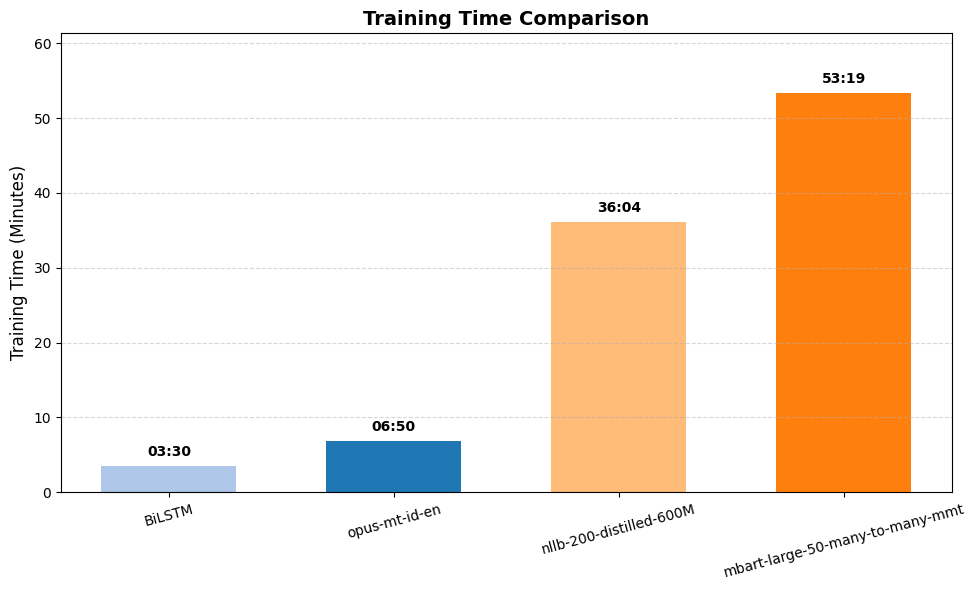

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BiLSTM', 'opus-mt-id-en', 'nllb-200-distilled-600M', 'mbart-large-50-many-to-many-mmt']
raw_times = ['03:30', '06:50', '36:04', '53:19']

minutes_values = []

for t in raw_times:
    parts = t.split(':')
    m = int(parts[0])
    s = int(parts[1])
    minutes_values.append(m + s/60.0)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e']

bars = ax.bar(models, minutes_values, color=colors, width=0.6)

ax.set_ylabel('Training Time (Minutes)', fontsize=12)
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=15, ha='center')

for bar, raw_label in zip(bars, raw_times):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{raw_label}",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylim(0, max(minutes_values) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Analisis

In [ ]:
!pip install evaluate sacremoses sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.8 MB/s eta 0:00:00


In [ ]:
import evaluate

In [ ]:
import pandas as pd

helsinki2 = pd.read_csv("helsinki_results2.csv")
nllb2 = pd.read_csv("nllb_results2.csv")
mbart2 = pd.read_csv("mbart_results2.csv")

In [ ]:
helsinki2 = helsinki2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_helsinki_baseline', 'pred_helsinki_finetuned' ]]
nllb2 = nllb2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_nllb_baseline', 'pred_nllb_finetuned']]
mbart2 = mbart2[['id', 'text', 'english_translation', 'better_english_translation', 'mbart_baseline', 'mbart_finetuned']]

In [ ]:
helsinki2_eng_base = helsinki2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_helsinki_baseline']]
helsinki2_eng_fine = helsinki2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_helsinki_finetuned']]
# helsinki2_better_base = helsinki2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_helsinki_baseline']]
# helsinki2_better_fine = helsinki2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_helsinki_finetuned']]

nllb2_eng_base = nllb2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_nllb_baseline']]
nllb2_eng_fine = nllb2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_nllb_finetuned']]
# nllb2_better_base = nllb2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_nllb_baseline']]
# nllb2_better_fine = nllb2[['id', 'text', 'english_translation', 'better_english_translation', 'pred_nllb_finetuned']]

mbart2_eng_base = mbart2[['id', 'text', 'english_translation', 'better_english_translation','mbart_baseline']]
mbart2_eng_fine = mbart2[['id', 'text', 'english_translation', 'better_english_translation', 'mbart_finetuned']]
# mbart2_better_base = mbart2[['id', 'text', 'english_translation', 'better_english_translation', 'mbart_baseline']]
# mbart2_better_fine = mbart2[['id', 'text', 'english_translation', 'better_english_translation', 'mbart_finetuned']]

In [ ]:
import pandas as pd
import evaluate

bleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")

def get_dual_score_df(df, pred_col, metric_type="bleu"):
    """
    Creates a new DataFrame with scores against both English references.
    metric_type: 'bleu' or 'meteor'
    """
    res_df = df.copy()

    required_cols = ['english_translation', 'better_english_translation', pred_col]
    if not all(col in res_df.columns for col in required_cols):
        print(f"⚠️ Missing columns for {pred_col}. Skipping...")
        return None

    scores_std = []
    scores_better = []

    print(f"Calculating {metric_type.upper()} for {pred_col}...")

    for _, row in res_df.iterrows():
        pred = [row[pred_col]]
        ref_std = [[row['english_translation']]]
        ref_better = [[row['better_english_translation']]]

        if metric_type == "bleu":
            s_std = bleu_metric.compute(predictions=pred, references=ref_std, use_effective_order=True)['score']
            s_bet = bleu_metric.compute(predictions=pred, references=ref_better, use_effective_order=True)['score']

        elif metric_type == "meteor":
            s_std = meteor_metric.compute(predictions=pred, references=ref_std)['meteor']
            s_bet = meteor_metric.compute(predictions=pred, references=ref_better)['meteor']

        scores_std.append(s_std)
        scores_better.append(s_bet)

    col_name_std = f"{metric_type.upper()}_vs_Std"
    col_name_better = f"{metric_type.upper()}_vs_Better"

    res_df[col_name_std] = scores_std
    res_df[col_name_better] = scores_better

    return res_df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
helsinki_base_bleu = get_dual_score_df(helsinki2_eng_base, "pred_helsinki_baseline", "bleu")
helsinki_fine_bleu = get_dual_score_df(helsinki2_eng_fine, "pred_helsinki_finetuned", "bleu")
helsinki_base_meteor = get_dual_score_df(helsinki2_eng_base, "pred_helsinki_baseline", "meteor")
helsinki_fine_meteor = get_dual_score_df(helsinki2_eng_fine, "pred_helsinki_finetuned", "meteor")

nllb_base_bleu = get_dual_score_df(nllb2_eng_base, "pred_nllb_baseline", "bleu")
nllb_fine_bleu = get_dual_score_df(nllb2_eng_fine, "pred_nllb_finetuned", "bleu")
nllb_base_meteor = get_dual_score_df(nllb2_eng_base, "pred_nllb_baseline", "meteor")
nllb_fine_meteor = get_dual_score_df(nllb2_eng_fine, "pred_nllb_finetuned", "meteor")

mbart_base_bleu = get_dual_score_df(mbart2_eng_base, "mbart_baseline", "bleu")
mbart_fine_bleu = get_dual_score_df(mbart2_eng_fine, "mbart_finetuned", "bleu")
mbart_base_meteor = get_dual_score_df(mbart2_eng_base, "mbart_baseline", "meteor")
mbart_fine_meteor = get_dual_score_df(mbart2_eng_fine, "mbart_finetuned", "meteor")

Calculating BLEU for pred_helsinki_baseline...
Calculating BLEU for pred_helsinki_finetuned...
Calculating METEOR for pred_helsinki_baseline...
Calculating METEOR for pred_helsinki_finetuned...
Calculating BLEU for pred_nllb_baseline...
Calculating BLEU for pred_nllb_finetuned...
Calculating METEOR for pred_nllb_baseline...
Calculating METEOR for pred_nllb_finetuned...
Calculating BLEU for mbart_baseline...
Calculating BLEU for mbart_finetuned...
Calculating METEOR for mbart_baseline...
Calculating METEOR for mbart_finetuned...


In [ ]:
import pandas as pd

all_dfs = {
    "Helsinki Base (BLEU)": helsinki_base_bleu,
    "Helsinki Fine (BLEU)": helsinki_fine_bleu,
    "Helsinki Base (METEOR)": helsinki_base_meteor,
    "Helsinki Fine (METEOR)": helsinki_fine_meteor,

    "NLLB Base (BLEU)": nllb_base_bleu,
    "NLLB Fine (BLEU)": nllb_fine_bleu,
    "NLLB Base (METEOR)": nllb_base_meteor,
    "NLLB Fine (METEOR)": nllb_fine_meteor,

    "mBART Base (BLEU)": mbart_base_bleu,
    "mBART Fine (BLEU)": mbart_fine_bleu,
    "mBART Base (METEOR)": mbart_base_meteor,
    "mBART Fine (METEOR)": mbart_fine_meteor,
}

percentile_results = {}

for name, df in all_dfs.items():

    if 'BLEU_vs_Std' in df.columns:
        sort_col = 'BLEU_vs_Std'
        secondary_col = 'BLEU_vs_Better'
    elif 'METEOR_vs_Std' in df.columns:
        sort_col = 'METEOR_vs_Std'
        secondary_col = 'METEOR_vs_Better'
    else:
        print(f"Skipping {name}: Could not find Score columns.")
        continue

    sorted_df = df.sort_values(by=sort_col).reset_index(drop=True)

    n = len(sorted_df)
    percentiles = [0.10, 0.30, 0.50, 0.70, 0.90, 0.95, 1]
    indices = [int((n - 1) * p) for p in percentiles]

    result = sorted_df.iloc[indices].copy()

    result['Percentile'] = [f"{int(p*100)}%" for p in percentiles]


    excluded_cols = ['text', 'english_translation', 'better_english_translation',
                     'Percentile', sort_col, secondary_col, 'id']

    pred_col = [c for c in result.columns if c not in excluded_cols]

    display_cols = ['text', 'english_translation', 'better_english_translation'] + \
                   pred_col + \
                   [sort_col, secondary_col, 'Percentile']

    final_cols = [c for c in display_cols if c in result.columns]

    result_ordered = result[final_cols].fillna('')
    percentile_results[name] = result_ordered

In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print

print("\n🔵 HELSINKI - Base (BLEU)")
display(percentile_results['Helsinki Base (BLEU)'])

print("\n🔵 HELSINKI - Fine (BLEU)")
display(percentile_results['Helsinki Fine (BLEU)'])

print("\n🔵 HELSINKI - Base (METEOR)")
display(percentile_results['Helsinki Base (METEOR)'])

print("\n🔵 HELSINKI - Fine (METEOR)")
display(percentile_results['Helsinki Fine (METEOR)'])


print("\n" + "="*80)
print("\n🟠 NLLB - Base (BLEU)")
display(percentile_results['NLLB Base (BLEU)'])

print("\n🟠 NLLB - Fine (BLEU)")
display(percentile_results['NLLB Fine (BLEU)'])

print("\n🟠 NLLB - Base (METEOR)")
display(percentile_results['NLLB Base (METEOR)'])

print("\n🟠 NLLB - Fine (METEOR)")
display(percentile_results['NLLB Fine (METEOR)'])


print("\n" + "="*80)
print("\n🟣 mBART - Base (BLEU)")
display(percentile_results['mBART Base (BLEU)'])

print("\n🟣 mBART - Fine (BLEU)")
display(percentile_results['mBART Fine (BLEU)'])

print("\n🟣 mBART - Base (METEOR)")
display(percentile_results['mBART Base (METEOR)'])

print("\n🟣 mBART - Fine (METEOR)")
display(percentile_results['mBART Fine (METEOR)'])


🔵 HELSINKI - Base (BLEU)


,text,english_translation,better_english_translation,pred_helsinki_baseline,BLEU_vs_Std,BLEU_vs_Better,Percentile
19,depannya sih lumayan bagus banyak bunganya dan...,"In front, it's quite nice with many flowers an...",The front area is quite nice with lots of flow...,"fontcolor="" # FFFF00""the frontisgood fontcolor...",0.813035,0.813035,10%
59,must visited place kalo ke lembang harga tiket...,Must-visit place if you go to Lembang. Entranc...,A must-visit place if you're in Lembang. The e...,Must have been a visit place. If the ticket ra...,3.218755,1.438772,30%
99,tempatnya keren bagus buat foto foto dengan la...,"The place is cool, great for taking photos wit...","The place is cool, great for photos with a bac...",It's a cool place to shoot photos with river b...,7.819843,5.568968,50%
139,sejuk tempat luas buat olahraga jalan kaki nai...,"cool spacious place for walking exercise, up a...","A cool and spacious place for exercise, walkin...",It's a nice big place for the sport to walk up...,12.512237,10.978766,70%
179,nice place for camping and hiking jalannya aga...,nice place for camping and hiking the road is ...,Nice place for camping and hiking. The road is...,nice place for camping and hiking the road is ...,30.077053,11.558678,90%
189,viewnya bagus cuma capek naik keatasnya tapi s...,"The view is good, it's just tiring to go up, b...","The view is great, but the climb is tiring. It...","The view is good. It's just tired of going up,...",36.823620,12.447871,95%
199,sayangnya airnya kotor dengan limbah rumah tan...,"Unfortunately, the water is dirty with househo...","Unfortunately, the water is dirty with househo...",Unfortunately the water is dirty with househol...,62.628450,38.156706,100%



🔵 HELSINKI - Fine (BLEU)


,text,english_translation,better_english_translation,pred_helsinki_finetuned,BLEU_vs_Std,BLEU_vs_Better,Percentile
19,cikole tmp outbound yang recommended banget ke...,Cikole is highly recommended for outbound beca...,Cikole is a highly recommended outbound spot. ...,Cikole Tmp Outbound is very recommended. Why i...,9.889192,8.667591,10%
59,sampahnya masih banyak mohon diperketat lagi a...,"The trash is still a lot, please tighten the r...","There is still a lot of trash, please tighten ...","The trash is still full, please strengthen it ...",22.250253,8.233515,30%
99,tempat wisata yang menarik untuk dikunjungi ol...,An interesting tourist spot to visit for those...,An interesting tourist attraction for those wh...,An interesting tourist spot to visit by natura...,30.064357,11.665984,50%
139,nice place for camping and hiking jalannya aga...,nice place for camping and hiking the road is ...,Nice place for camping and hiking. The road is...,nice place for camping and hiking. The road is...,39.375019,46.821977,70%
179,the best place lumayan trackingnya nanjak dan ...,"The best place, the tracking is okay, with ups...",The best place. The hike is pretty challenging...,"The best place is quite a trail, uphill and do...",57.675043,14.957644,90%
189,tempatnya bagus indah penuh dengan berbagai ma...,"The place is nice, beautiful, full of various ...","The place is beautiful, filled with a variety ...","The place is nice, beautiful, full of various ...",69.390296,37.955432,95%
199,tempatnya enak buat hiking makanan cukup terja...,"The place is nice for hiking, the food is quit...",The place is nice for hiking and the food is r...,"The place is nice for hiking, the food is quit...",100.000000,49.735674,100%



🔵 HELSINKI - Base (METEOR)


...

,text,english_translation,better_english_translation,mbart_finetuned,BLEU_vs_Std,BLEU_vs_Better,Percentile
19,depannya sih lumayan bagus banyak bunganya dan...,"In front, it's quite nice with many flowers an...",The front area is quite nice with lots of flow...,"The front is quite good, there are many flower...",13.752542,7.087649,10%
59,datang kesini kebetulan pas lagi hujan berkabu...,Came here coincidentally when it was raining a...,I happened to arrive when it was rainy and fog...,"Came here by chance, when it rained and fogged...",26.069431,17.867862,30%
99,tempat wisata yang sangat jelek tidak diurus b...,"A very ugly tourist spot, neglected, full of t...","A very bad tourist attraction, it is unmaintai...","A very bad tourist spot, not well maintained, ...",36.750589,38.249626,50%
139,tempat wisata yang berada di kawasan bandung b...,"Tourist spot located in the West Bandung area,...",A tourist attraction in the West Bandung area....,A tourist spot located in the West Bandung are...,44.702964,22.015274,70%
179,tempatnya bagus instagramable adem cuma enggak...,"The place is good, instagrammable, and cool, b...","The place is nice, Instagrammable, and cool, b...","The place is nice, Instagrammable, cool, but y...",63.971593,85.224567,90%
189,curug cimahi best view harus kesini kalo ke ba...,"Curug Cimahi, best view, you must come here if...","Curug Cimahi has the best view, you have to co...","Curug Cimahi, best view. You should come here ...",67.390471,15.207795,95%
199,jalur pendakian sudah bagus tapi setelah memba...,"The hiking trail is good, but after paying, we...","The hiking trail is good, but after paying, we...","The hiking trail is already good, but after pa...",89.422555,52.082026,100%



🟣 mBART - Base (METEOR)


,text,english_translation,better_english_translation,mbart_baseline,METEOR_vs_Std,METEOR_vs_Better,Percentile
19,selalu senang walau pun krja tak ada libur jal...,"Happy even though there's no work holiday, I'l...","Always happy, even though I work with no days ...","Always happy, even if you don't have a holiday...",0.200000,0.247437,10%
59,kalo ke lembang harus kesini tempatnya sejuk b...,"When going to Lembang, you must come here. The...","If you go to Lembang, you have to come here. T...","The reptiles had to go to cool places, they co...",0.308977,0.409599,30%
99,saya deh 2x kesini sok far bisa bikin anak-ana...,"I've been here twice already, and it always ma...","I've been here twice and so far, it has manage...","I've eaten twice as much sour cream, I can mak...",0.377813,0.365327,50%
139,untuk kebun bunganya sangat terawat tapi untuk...,"For the flower garden, it's very well-maintain...","The flower garden is very well-maintained, but...","For a garden, it's a very careful flower, but ...",0.461758,0.423383,70%
179,harga tiket masuk 20ribuan per orang lokasi se...,"Entrance ticket price around 20,000 per person...","The entrance fee is around 20,000 per person. ...","The ticket price was 20,000 dollars per person...",0.608407,0.421628,90%
189,sampahnya masih banyak mohon diperketat lagi a...,"The trash is still a lot, please tighten the r...","There is still a lot of trash, please tighten ...","There's still a lot of trash left, so please t...",0.652569,0.614149,95%
199,destinasi wisata yang sangat indah dihiasi den...,A very beautiful tourist destination adorned w...,A very beautiful tourist destination adorned w...,"It's a very beautiful tourist destination, ado...",0.962012,0.973351,100%



🟣 mBART - Fine (METEOR)


,text,english_translation,better_english_translation,mbart_finetuned,METEOR_vs_Std,METEOR_vs_Better,Percentile
19,tempat indah dan sejuk buat berlibur bersama k...,Beautiful and cool place to holiday with famil...,A beautiful and cool place for a vacation with...,A beautiful and cool place for a holiday with ...,0.517352,0.515559,10%
59,tempat rekreasi keluar cocok untuk anak kecil ...,A recreational spot suitable for young childre...,"An outdoor recreational spot, great for kids. ...",A recreational place suitable for small childr...,0.606403,0.513743,30%
99,must visited place kalo ke lembang harga tiket...,Must-visit place if you go to Lembang. Entranc...,A must-visit place if you're in Lembang. The e...,"Must-visit place. If you go to Lembang, the en...",0.692687,0.600289,50%
139,- kebun atau kebun raya yang dipenuhi anggrek ...,- A garden or botanical garden filled with orc...,- A garden or botanical garden filled with orc...,- A garden or a park filled with orchids - The...,0.772557,0.782867,70%
179,tempatnya bagus banyak penjual lokal kalo kesi...,"The place is nice, with many local vendors. If...",The place is nice with many local vendors. If ...,"The place is nice, there are many local vendor...",0.894881,0.888260,90%
189,tempatnya indah sekali romantis banyak spot fo...,"The place is very beautiful and romantic, with...","The place is very beautiful and romantic, with...","The place is very beautiful, romantic, with ma...",0.920307,0.855670,95%
199,sebuah tempat rekreasi keluarga yang sudah ada...,a family recreation place that has existed sin...,A family recreation spot that has been around ...,A family recreation spot that has existed sinc...,0.999500,0.529487,100%


In [ ]:
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

comparison_pairs = [
    ("Helsinki", helsinki_base_bleu, helsinki_fine_bleu, "pred_helsinki_baseline", "pred_helsinki_finetuned"),
    ("NLLB", nllb_base_bleu, nllb_fine_bleu, "pred_nllb_baseline", "pred_nllb_finetuned"),
    ("mBART", mbart_base_bleu, mbart_fine_bleu, "mbart_baseline", "mbart_finetuned"),
]

std_col = 'BLEU_vs_Std'
better_col = 'BLEU_vs_Better'

for title, df_base, df_fine, col_base, col_fine in comparison_pairs:

    print(f"\n{'#'*80}")
    print(f"  TOP 5 IMPROVEMENTS (Sorted by Standard English): {title}")
    print(f"{'#'*80}")

    combined = df_base[['text', 'english_translation', 'better_english_translation',
                        col_base, std_col, better_col]].copy()

    combined = combined.rename(columns={
        std_col: 'Std_Base',
        better_col: 'Better_Base',
        col_base: 'Base_Pred'
    })

    combined['Fine_Pred'] = df_fine[col_fine]
    combined['Std_Fine'] = df_fine[std_col]
    combined['Better_Fine'] = df_fine[better_col]

    combined['Imp_Std'] = combined['Std_Fine'] - combined['Std_Base']
    combined['Imp_Better'] = combined['Better_Fine'] - combined['Better_Base']

    top_5 = combined.sort_values(by='Imp_Std', ascending=False).head(5)

    display_cols = [
        'text',
        'english_translation',
        'better_english_translation',
        'Base_Pred',
        'Fine_Pred',
        'Std_Base', 'Std_Fine', 'Imp_Std',
        'Better_Base', 'Better_Fine', 'Imp_Better'
    ]

    display(top_5[display_cols])


################################################################################
  TOP 5 IMPROVEMENTS (Sorted by Standard English): Helsinki
################################################################################


,text,english_translation,better_english_translation,Base_Pred,Fine_Pred,Std_Base,Std_Fine,Imp_Std,Better_Base,Better_Fine,Imp_Better
13,tempatnya enak buat hiking makanan cukup terja...,"The place is nice for hiking, the food is quit...",The place is nice for hiking and the food is r...,It's a good place to go. Food hiking is quite ...,"The place is nice for hiking, the food is quit...",21.401603,100.000000,78.598397,4.368584,49.735674,45.367090
52,tempatnya bagus pelayanan ok pilihan roomnya j...,"The place is nice, the service is okay, the ro...","The place is nice, the service is okay, and th...",It's nice. It's nice. It's nice.,"The place is nice, the service is okay, the ro...",1.070885,74.322548,73.251663,0.857498,64.925777,64.068279
125,tempatnya bagus indah penuh dengan berbagai ma...,"The place is nice, beautiful, full of various ...","The place is beautiful, filled with a variety ...",It's nice. It's beautiful. It's full of differ...,"The place is nice, beautiful, full of various ...",1.601660,69.390296,67.788636,1.720249,37.955432,36.235182
61,tempatnya indah sekali romantis banyak spot fo...,"The place is very beautiful and romantic, with...","The place is very beautiful and romantic, with...",It's beautiful. It's so romantic. Lots of photos.,"The place is beautiful, romantic, with many go...",1.130073,67.826522,66.696449,1.091070,64.150272,63.059202
160,tempat nyaman untuk berlibur bersama keluarga ...,"a comfortable place to vacation with family, h...","A comfortable place for a family vacation, rec...",It's a nice place to go on vacation with the r...,"A comfortable place to vacation with family, r...",7.994607,72.415773,64.421166,3.493384,59.460356,55.966972



################################################################################
  TOP 5 IMPROVEMENTS (Sorted by Standard English): NLLB
################################################################################


,text,english_translation,better_english_translation,Base_Pred,Fine_Pred,Std_Base,Std_Fine,Imp_Std,Better_Base,Better_Fine,Imp_Better
65,tempatnya keren banget spot fotonya banyak coc...,"The place is really cool, there are many photo...",The place is really cool with lots of photo sp...,It's a really cool place. It's a great place f...,"The place is really cool, there are many photo...",7.072808,78.508293,71.435485,12.975281,32.225386,19.250105
24,tempatnya bagus banyak penjual lokal kalo kesi...,"The place is nice, with many local vendors. If...",The place is nice with many local vendors. If ...,It's a nice place. There's a lot of local vend...,"The place is nice, there are many local vendor...",3.344968,72.716486,69.371518,3.635659,68.596084,64.960425
61,tempatnya indah sekali romantis banyak spot fo...,"The place is very beautiful and romantic, with...","The place is very beautiful and romantic, with...",It's a lovely romantic place. A lot of good ph...,"The place is very beautiful, romantic, with ma...",3.275600,69.611291,66.335690,3.088475,59.511819,56.423344
178,tempatnya sebenarnya enggak gede banget enggak...,"The place isn't actually very big, it doesn't ...","The place is actually not that big, it doesn't...",It's not really that big. It doesn't take long...,"The place isn't really very big, it doesn't ta...",18.962195,80.927192,61.964997,20.296139,78.732420,58.436282
122,harga masuknya murah per orang hanya sekitar 1...,"The entrance fee is cheap, only around 10 thou...","The entrance fee is cheap, only around 10,000 ...",The price of admission is cheap per person onl...,"The entrance fee is cheap, only about 10 thous...",12.311326,72.923764,60.612438,9.184694,54.147513,44.962819



################################################################################
  TOP 5 IMPROVEMENTS (Sorted by Standard English): mBART
################################################################################


,text,english_translation,better_english_translation,Base_Pred,Fine_Pred,Std_Base,Std_Fine,Imp_Std,Better_Base,Better_Fine,Imp_Better
178,tempatnya sebenarnya enggak gede banget enggak...,"The place isn't actually very big, it doesn't ...","The place is actually not that big, it doesn't...",It's actually a place where it takes a long ti...,"The place isn't really big, it doesn't take lo...",4.500665,89.105292,84.604627,4.411499,75.706377,71.294878
119,bagus mini bali tempatnya lumayan luas harga m...,"Good mini Bali, the place is quite spacious, t...","A nice mini Bali. The place is quite spacious,...","It's nice, it's spacious, it's affordable, the...","Good mini Bali, the place is quite spacious, t...",5.375659,83.181801,77.806142,4.964659,51.376188,46.411529
125,tempatnya bagus indah penuh dengan berbagai ma...,"The place is nice, beautiful, full of various ...","The place is beautiful, filled with a variety ...","It's nice, it's beautiful, it's full of differ...","The place is nice, beautiful, full of various ...",3.751147,77.037251,73.286104,2.811988,33.045635,30.233648
2,tempatnya asri adem cocok bawa main anak-anak ...,"The place is beautiful and cool, suitable for ...","The place is serene and cool, perfect for brin...","It's a nice place with a lot of cool air, lots...","The place is beautiful and cool, suitable for ...",1.930005,67.450160,65.520155,3.778411,24.264618,20.486206
120,curug cimahi best view harus kesini kalo ke ba...,"Curug Cimahi, best view, you must come here if...","Curug Cimahi has the best view, you have to co...",The best-viewed spiderweb is the one that cuts...,"Curug Cimahi, best view. You should come here ...",2.916496,67.390471,64.473975,2.988663,15.207795,12.219132


In [ ]:
import pandas as pd

def create_summary_df(df_base, df_fine, base_pred_col, fine_pred_col, metric_prefix):
    """
    Merges Base and Fine dataframes and calculates improvements.
    metric_prefix: 'BLEU' or 'METEOR'
    """

    summary = df_base.copy()


    summary['Fine_Pred'] = df_fine[fine_pred_col]


    summary = summary.rename(columns={
        base_pred_col: 'Base_Pred',
        f'{metric_prefix}_vs_Std': 'Std_Base',
        f'{metric_prefix}_vs_Better': 'Better_Base'
    })

    summary['Std_Fine'] = df_fine[f'{metric_prefix}_vs_Std']
    summary['Better_Fine'] = df_fine[f'{metric_prefix}_vs_Better']

    summary['Imp_Std'] = summary['Std_Fine'] - summary['Std_Base']
    summary['Imp_Better'] = summary['Better_Fine'] - summary['Better_Base']

    final_cols = [
        'text',
        'english_translation',
        'better_english_translation',
        'Base_Pred',
        'Fine_Pred',
        'Std_Base',
        'Std_Fine',
        'Imp_Std',
        'Better_Base',
        'Better_Fine',
        'Imp_Better'
    ]

    return summary[final_cols]


summary_dfs = {}


summary_dfs['Helsinki_BLEU'] = create_summary_df(
    helsinki_base_bleu, helsinki_fine_bleu,
    "pred_helsinki_baseline", "pred_helsinki_finetuned", "BLEU"
)
summary_dfs['Helsinki_METEOR'] = create_summary_df(
    helsinki_base_meteor, helsinki_fine_meteor,
    "pred_helsinki_baseline", "pred_helsinki_finetuned", "METEOR"
)

summary_dfs['NLLB_BLEU'] = create_summary_df(
    nllb_base_bleu, nllb_fine_bleu,
    "pred_nllb_baseline", "pred_nllb_finetuned", "BLEU"
)
summary_dfs['NLLB_METEOR'] = create_summary_df(
    nllb_base_meteor, nllb_fine_meteor,
    "pred_nllb_baseline", "pred_nllb_finetuned", "METEOR"
)

summary_dfs['mBART_BLEU'] = create_summary_df(
    mbart_base_bleu, mbart_fine_bleu,
    "mbart_baseline", "mbart_finetuned", "BLEU"
)
summary_dfs['mBART_METEOR'] = create_summary_df(
    mbart_base_meteor, mbart_fine_meteor,
    "mbart_baseline", "mbart_finetuned", "METEOR"
)

In [ ]:
import pandas as pd

def merge_metric_dfs(df_bleu, df_meteor):
    """
    Merges BLEU and METEOR dataframes into a single wide dataframe.
    """
    # 1. Define shared columns (keys)
    shared_cols = ['text', 'english_translation', 'better_english_translation', 'Base_Pred', 'Fine_Pred']

    # 2. Rename the score columns to avoid conflicts
    score_cols = ['Std_Base', 'Std_Fine', 'Imp_Std', 'Better_Base', 'Better_Fine', 'Imp_Better']

    # Rename BLEU cols
    bleu_renamed = df_bleu.rename(columns={c: f"{c}_BLEU" for c in score_cols})

    # Rename METEOR cols
    meteor_renamed = df_meteor[score_cols].rename(columns={c: f"{c}_METEOR" for c in score_cols})

    # 3. Concatenate
    merged_df = pd.concat([bleu_renamed, meteor_renamed], axis=1)

    return merged_df


combined_dfs = {}

# 1. Helsinki
combined_dfs['Helsinki_Combined'] = merge_metric_dfs(summary_dfs['Helsinki_BLEU'], summary_dfs['Helsinki_METEOR'])

# 2. NLLB
combined_dfs['NLLB_Combined'] = merge_metric_dfs(summary_dfs['NLLB_BLEU'], summary_dfs['NLLB_METEOR'])

# 3. mBART
combined_dfs['mBART_Combined'] = merge_metric_dfs(summary_dfs['mBART_BLEU'], summary_dfs['mBART_METEOR'])



In [ ]:
display_sample = combined_dfs['mBART_Combined'].sort_values('Imp_Better_METEOR', ascending=False).head()
display(display_sample)

,text,english_translation,better_english_translation,Base_Pred,Fine_Pred,Std_Base_BLEU,Std_Fine_BLEU,Imp_Std_BLEU,Better_Base_BLEU,Better_Fine_BLEU,Imp_Better_BLEU,Std_Base_METEOR,Std_Fine_METEOR,Imp_Std_METEOR,Better_Base_METEOR,Better_Fine_METEOR,Imp_Better_METEOR
13,tempatnya enak buat hiking makanan cukup terjangkau harganya,"The place is nice for hiking, the food is quite affordable.",The place is nice for hiking and the food is reasonably priced.,"It's delicious for hiking, it's pretty affordable.","The place is nice for hiking, the food is quite affordable and the prices are reasonable.",14.308697,64.701071,50.392374,6.766165,36.615108,29.848942,0.378125,0.935569,0.557444,0.199653,0.887793,0.688140
166,enak banget suasana kalo sore banyak saung juga untuk istirahat pemandangan keren udara sejuk,"It feels really good when it's evening, there are also many gazebos to rest, the scenery is cool, the air is fresh.","The atmosphere is very nice in the afternoon. There are also many gazebos to rest in, the scenery is cool, and the air is fresh.",It's delicious. It's cool in the afternoon. There's lots of freezers to take a break from. It's cool in the evening.,"The atmosphere is really nice in the afternoon, there are also many gazebos to rest in. The view is cool, the air is cool.",2.264882,42.689518,40.424636,9.840924,42.445842,32.604918,0.233640,0.594619,0.360980,0.172414,0.828208,0.655794
178,tempatnya sebenarnya enggak gede banget enggak butuh waktu lama buat jelajahin semua titik spot foto di sana tiket masuknya murah cuma 15rb saja tempatnya sejuk,"The place isn't actually very big, it doesn't take long to explore all the photo spots there. The entrance ticket is cheap, only 15 thousand. The place is cool.","The place is actually not that big, it doesn't take long to explore all the photo spots there. The entrance ticket is cheap, only 15,000. The place is cool.","It's actually a place where it takes a long time to get all the spotlights, and it's cheap, it's 15 bucks, it's cool.","The place isn't really big, it doesn't take long to explore all the photo spots there. The entrance ticket is cheap, only 15 thousand. The place is cool.",4.500665,89.105292,84.604627,4.411499,75.706377,71.294878,0.250767,0.946979,0.696212,0.242642,0.885313,0.642671
189,tempatnya bagus bisa buat piknik kumpul-kumpul keluarga teman viewnya bagus buat foto-foto,"The place is nice, good for picnics and family/friend gatherings. The view is great for taking photos.","The place is nice, good for picnics and gatherings with family and friends. The view is great for taking photos.","It's a great place to have picnics, gather family friends, take pictures.","The place is nice, suitable for picnics, gathering with family, friends, and the view is good for taking photos.",2.579206,31.146378,28.567171,2.507667,32.850641,30.342974,0.178571,0.789911,0.611340,0.201794,0.826353,0.624559
76,tempat wisata yang asik dan menyenangkan tiket masuknya cukup terjangkau walaupun hanya melihat kawah namun pikiran terasa jernih penat penat pun hilang hindari kesini saat musim liburan saat kesini wajib makan indomie dan jagung bakar hahhaa,"A fun and enjoyable tourist spot. The entrance fee is quite affordable. Even though you're only looking at the crater, your mind feels clear and your fatigue disappears. Avoid coming here during the holiday season. When you come here, you must eat Indomie and grilled corn, hahaha.","A fun and enjoyable tourist spot, the entrance ticket is quite affordable. Even though you only see a crater, your mind feels clear and the fatigue disappears. Avoid coming here during the holiday season. When you're here, you must eat Indomie and grilled corn, hahaha.","It's a thrilling place to be, and the ticket is affordable, even if you only look at the whales, but the mind is still fresh, and you lose sight of the hustle and bustle of the holiday season when you're hungry, when you're craving for indigenous food and hashish.","A fun and enjoyable t